# 09 - Traffic Jam Classification from Predictions

Convert the continuous `vehicle_count` predictions logged in `results/predictions.csv` (from notebooks 05–07) into low/moderate/high traffic density categories, using the same quantile-based thresholds as `density_category` in notebook 03. Evaluates each model's classification accuracy at identifying traffic congestion level, not just the raw count.

Output: `results/jam_classification.csv`, `results/jam_classification_accuracy.csv`, figures saved to `results/figures/`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix

sys.path.append("..")

from src.data_utils import drop_incomplete_lag_rows, load_density_data, split_by_column, target_column

processed_dir = Path("../data/processed")
input_path = processed_dir / "traffic_density.csv"

predictions_path = Path("../results/predictions.csv")
figures_dir = Path("../results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

density_quantiles = [0.3, 0.6]
category_order = ["low", "moderate", "high"]

In [2]:
density = load_density_data(input_path)
density = drop_incomplete_lag_rows(density)

train_df, val_df, test_df = split_by_column(density)

In [3]:
low_threshold, high_threshold = train_df[target_column].quantile(density_quantiles)

print(f"low / moderate boundary: {low_threshold:.4f}")
print(f"moderate / high boundary: {high_threshold:.4f}")

low / moderate boundary: 2.4000
moderate / high boundary: 3.2400


In [4]:
def categorize_density(value, low_threshold, high_threshold):
    if value <= low_threshold:
        return "low"
    elif value <= high_threshold:
        return "moderate"
    else:
        return "high"

In [5]:
predictions_df = pd.read_csv(predictions_path)

predictions_df["actual_category"] = predictions_df["actual"].apply(categorize_density, args=(low_threshold, high_threshold))
predictions_df["predicted_category"] = predictions_df["predicted"].apply(categorize_density, args=(low_threshold, high_threshold))

predictions_df.to_csv("../results/jam_classification.csv", index=False)
predictions_df.head()

,model_name,split,actual,predicted,actual_category,predicted_category
0,linear_regression,test,4.866667,4.877292,high,high
1,linear_regression,test,4.800000,4.390115,high,high
2,linear_regression,test,5.733333,3.836889,high,high
3,linear_regression,test,4.733333,4.130282,high,high
4,linear_regression,test,6.400000,3.700308,high,high


In [6]:
model_names = predictions_df["model_name"].unique()

accuracy_results = []
for model_name in model_names:
    model_df = predictions_df[predictions_df["model_name"] == model_name]
    accuracy = accuracy_score(model_df["actual_category"], model_df["predicted_category"])
    accuracy_results.append(dict(model_name=model_name, accuracy=accuracy))
    print(f"{model_name} jam classification accuracy: {accuracy:.4f}")

accuracy_df = pd.DataFrame(accuracy_results)
accuracy_df.to_csv("../results/jam_classification_accuracy.csv", index=False)
accuracy_df

linear_regression jam classification accuracy: 0.8057
lstm jam classification accuracy: 0.8756
tcn jam classification accuracy: 0.8860
tcn_lstm_hybrid jam classification accuracy: 0.8264


,model_name,accuracy
0,linear_regression,0.805699
1,lstm,0.875648
2,tcn,0.886010
3,tcn_lstm_hybrid,0.826425


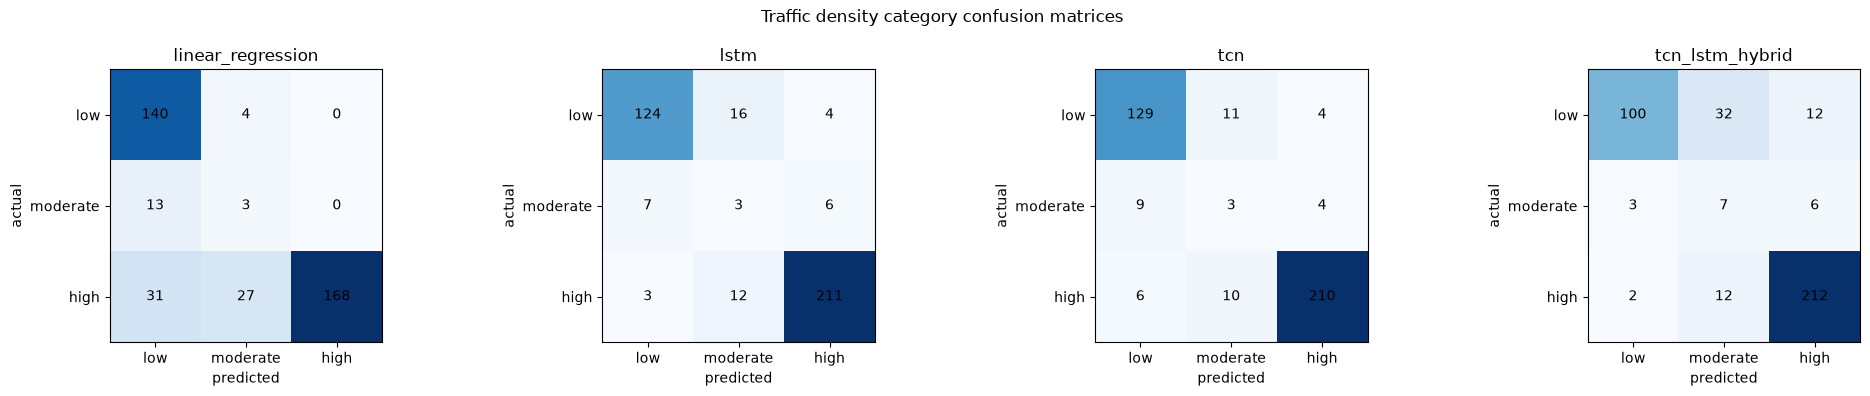

In [14]:
fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 4))
if len(model_names) == 1:
    axes = [axes]

for ax, model_name in zip(axes, model_names):
    model_df = predictions_df[predictions_df["model_name"] == model_name]
    cm = confusion_matrix(model_df["actual_category"], model_df["predicted_category"], labels=category_order)

    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(category_order)))
    ax.set_xticklabels(category_order)
    ax.set_yticks(range(len(category_order)))
    ax.set_yticklabels(category_order)
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")
    ax.set_title(model_name)

    for i in range(len(category_order)):
        for j in range(len(category_order)):
            ax.text(j, i, cm[i, j], ha="center", va="center")

fig.suptitle("Traffic density category confusion matrices")
fig.tight_layout()
fig.savefig(figures_dir / "jam_classification_confusion_matrices.png", dpi=300)
plt.show()

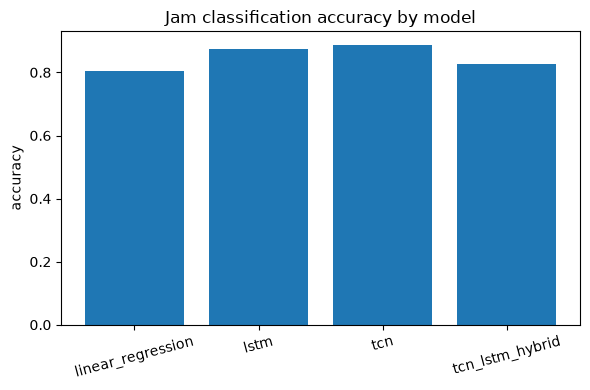

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(accuracy_df["model_name"], accuracy_df["accuracy"])
ax.set_ylabel("accuracy")
ax.set_title("Jam classification accuracy by model")
plt.xticks(rotation=15)

fig.tight_layout()
fig.savefig(figures_dir / "jam_classification_accuracy.png", dpi=300)
plt.show()